# Atividade 1 – Segmentação e Visão Computacional


Seções:
- Parte I: Limiarização (manual, Otsu, adaptativa)
- Parte II: Espaços de cor (RGB, HSV, L*a*b*)
- Parte III: Agrupamento k-means no plano a*b*
- Parte IV: Morfologia e refino das máscaras
- Análise comparativa final


In [29]:
from pathlib import Path
import sys

import numpy as np
import cv2
from skimage import color
import matplotlib.pyplot as plt

sys.path.append("../src")
from otsu import otsu_threshold

plt.rcParams["figure.figsize"] = (6, 4)

# Raiz do projeto = pai da pasta notebook/
ROOT = Path().resolve().parent
DATA_DIR = ROOT / "images" / "input"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT / "images" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Carregamento de imagem

Aqui ficam funções auxiliares para leitura e exibição das imagens da pasta `images/input`.


In [30]:
# carregamento da imagem RGB da pasta images/input
def load_rgb(name: str):
    """Carrega uma imagem RGB da pasta `images/input`."""
    path = DATA_DIR / name
    img_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

# show imagens lado a lado
def show_side_by_side(images, titles):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()


## Parte I – Limiarização Manual

Ponto de partida da segmentação: converter a imagem para escala de cinza e aplicar um limiar fixo T escolhido manualmente. O objetivo é entender o mecanismo básico e observar suas limitações antes de avançar para métodos automáticos.

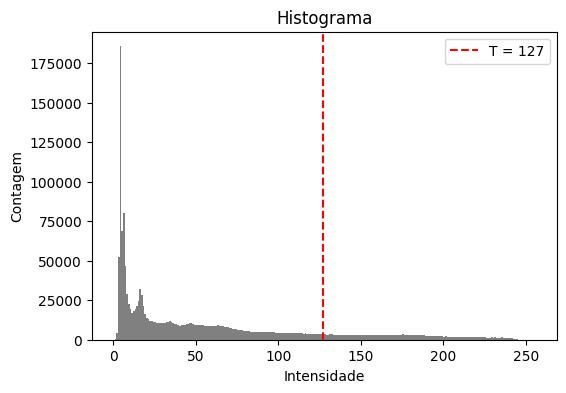

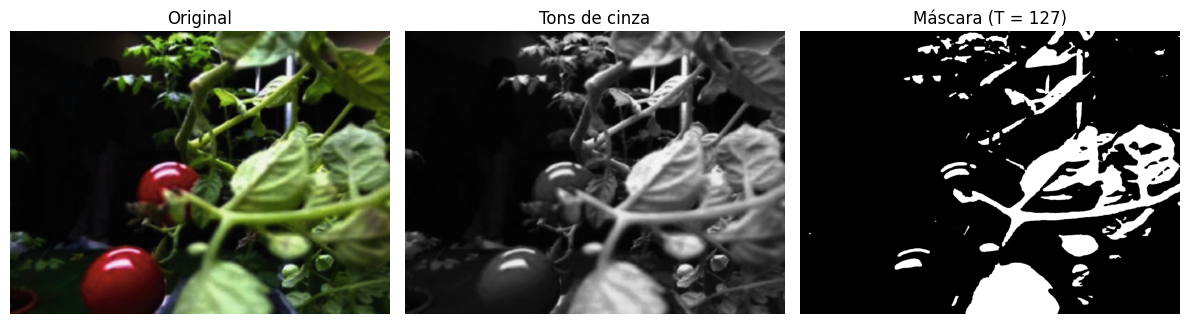

In [31]:
# Carrega a imagem colorida e converte para escala de cinza
img_rgb = load_rgb("tomates-corke.png")
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Limiar fixo escolhido manualmente — pixels >= T viram branco, demais preto
T = 127
mask = (img_gray >= T).astype(np.uint8) * 255

# Histograma da imagem em cinza com marcação visual do limiar escolhido
plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.axvline(T, color='red', linestyle='--', label=f'T = {T}')
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Contagem")
plt.legend()
plt.show()

# Comparação visual: original, cinza e máscara binária
show_side_by_side(
    [img_rgb, img_gray, mask],
    ["Original", "Tons de cinza", f"Máscara (T = {T})"]
)

## Parte I – Limiarização Método Otsu

Este bloco demonstra como chamar a função `otsu_threshold` (a ser implementada em `src/otsu.py`).


Limiar de Otsu: 90


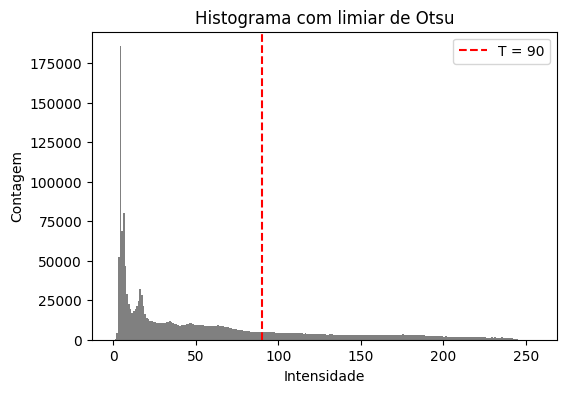

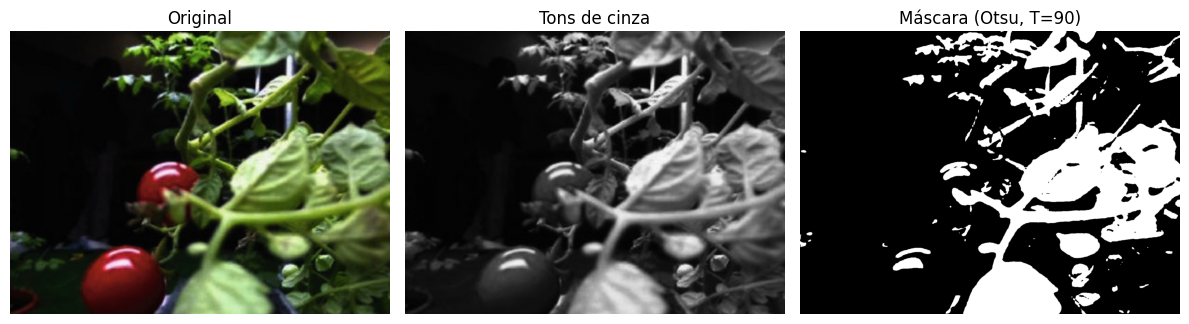

In [32]:
img_rgb = load_rgb("tomates-corke.png")  # ajuste o nome do arquivo se necessário
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

t = otsu_threshold(img_gray)
print("Limiar de Otsu:", t)

mask = (img_gray >= t).astype(np.uint8) * 255


# Histograma com o limiar de Otsu marcado
plt.hist(img_gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.axvline(t, color='red', linestyle='--', label=f'T = {t}')
plt.title("Histograma com limiar de Otsu")
plt.xlabel("Intensidade")
plt.ylabel("Contagem")
plt.legend()
plt.show()

show_side_by_side(
    [img_rgb, img_gray, mask],
    ["Original", "Tons de cinza", f"Máscara (Otsu, T={t})"]
)